In [1]:
import pandas as pd

In [2]:
path = "F:/major project/arxiv-metadata-oai-snapshot.json"

In [3]:
sample_df = pd.read_json(path, lines=True, nrows=200000)

In [4]:
print(sample_df.shape)
sample_df.head(5)

(200000, 14)


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,None,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,None,math.CO,None,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
4,704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,None,"Illinois J. Math. 52 (2008) no.2, 681-689",None,None,math.CA math.FA,None,In this paper we show how to compute the $\L...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]"


In [5]:
from collections import Counter

category_count = Counter()

for cats in sample_df['categories'].dropna():
    category_count.update(cats.split())

In [6]:
all_data = category_count.most_common()

newSample_df = pd.DataFrame(all_data, columns=['Category', 'Count'])

print(newSample_df)

           Category  Count
0          astro-ph  19875
1            hep-ph  18093
2            hep-th  17056
3          quant-ph  12801
4             gr-qc  10754
..              ...    ...
148  physics.app-ph      3
149        q-fin.EC      2
150         eess.SY      1
151         econ.GN      1
152         eess.AS      1

[153 rows x 2 columns]


In [7]:
qbio_df = newSample_df[newSample_df['Category'].str.contains('q-bio', na=False)]
print(qbio_df)

     Category  Count
76   q-bio.PE    917
78   q-bio.QM    865
85   q-bio.BM    589
94   q-bio.NC    446
99   q-bio.MN    425
113  q-bio.GN    289
114  q-bio.SC    279
121  q-bio.CB    241
131  q-bio.OT    161
135  q-bio.TO    141


In [8]:
from collections import Counter

category_count = Counter()

chunks = pd.read_json(path, lines=True, chunksize=10000)

for chunk in chunks:
    for cats in chunk['categories'].dropna():
        category_count.update(cats.split())

In [9]:
print(category_count.most_common(30))

[('cs.LG', 254055), ('hep-ph', 193922), ('cs.CV', 182139), ('hep-th', 180114), ('quant-ph', 174620), ('cs.AI', 163756), ('gr-qc', 119639), ('cond-mat.mtrl-sci', 106501), ('astro-ph', 105380), ('cs.CL', 102776), ('cond-mat.mes-hall', 99682), ('math-ph', 88340), ('math.MP', 88340), ('cond-mat.str-el', 81495), ('cond-mat.stat-mech', 80153), ('math.CO', 76323), ('stat.ML', 75866), ('astro-ph.CO', 75653), ('astro-ph.GA', 75512), ('math.AP', 72105), ('astro-ph.SR', 68125), ('astro-ph.HE', 67301), ('math.PR', 64203), ('nucl-th', 61712), ('math.OC', 59368), ('hep-ex', 59244), ('math.AG', 58440), ('physics.optics', 54738), ('cs.IT', 53186), ('math.IT', 53186)]


In [10]:
# get ALL categories
all_data = category_count.most_common()

df = pd.DataFrame(all_data, columns=['Category', 'Count'])

print(df)

     Category   Count
0       cs.LG  254055
1      hep-ph  193922
2       cs.CV  182139
3      hep-th  180114
4    quant-ph  174620
..        ...     ...
171   atom-ph     123
172  acc-phys      49
173  plasm-ph      38
174    ao-sci      17
175  bayes-an      16

[176 rows x 2 columns]


In [11]:
qbio_df = df[df['Category'].str.contains('q-bio', na=False)]
print(qbio_df)

     Category  Count
91   q-bio.QM  12756
92   q-bio.PE  12749
96   q-bio.NC  11700
121  q-bio.BM   6611
134  q-bio.MN   4091
136  q-bio.GN   3711
144  q-bio.TO   2582
146  q-bio.CB   2412
152  q-bio.SC   1790
156  q-bio.OT   1544
159     q-bio   1356


In [12]:
chunk_size = 100000
medical_data = []

for chunk in pd.read_json(path, lines=True, chunksize=chunk_size):
    filtered = chunk[chunk['categories'].str.contains('q-bio', na=False)]
    medical_data.append(filtered)

final_medical_df = pd.concat(medical_data)

In [13]:
final_medical_df.shape

(53862, 14)

In [14]:
final_medical_df.head(5)

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
20,704.0021,Yuichi Togashi,"Vanessa Casagrande, Yuichi Togashi, Alexander ...",Molecular Synchronization Waves in Arrays of A...,"5 pages, 4 figures","Phys. Rev. Lett. 99, 048301 (2007)",10.1103/PhysRevLett.99.048301,None,nlin.PS physics.chem-ph q-bio.MN,None,Spatiotemporal pattern formation in a produc...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-07-24,"[[Casagrande, Vanessa, ], [Togashi, Yuichi, ],..."
33,704.0034,Vasily Ogryzko V,Vasily Ogryzko,Origin of adaptive mutants: a quantum measurem...,5 pages,None,None,None,q-bio.PE q-bio.CB quant-ph,None,This is a supplement to the paper arXiv:q-bi...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Ogryzko, Vasily, ]]"
35,704.0036,Eduardo D. Sontag,Liming Wang and Eduardo D. Sontag,A remark on the number of steady states in a m...,Resubmit with new results on the upper bound o...,None,None,None,q-bio.QM q-bio.MN,None,The multisite phosphorylation-dephosphorylat...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2011-11-09,"[[Wang, Liming, ], [Sontag, Eduardo D., ]]"
157,704.0158,Huijie Yang,"Fangcui Zhao, Huijie Yang, and Binghong Wang",Complexities of Human Promoter Sequences,"5 pages, 3 figures, To appear in Journal of Th...",Journal of Theoretical Biology 247 (2007) 645?...,10.1016/j.jtbi.2007.03.035,None,q-bio.OT,None,"By means of the diffusion entropy approach, ...","[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2011-11-09,"[[Zhao, Fangcui, ], [Yang, Huijie, ], [Wang, B..."
190,704.0191,Peter Virnau,"Peter Virnau (1), Leonid A. Mirny (1,2), Mehra...",Intricate Knots in Proteins: Function and Evol...,"6 pages, 2 figures, 1 table","P. Virnau, L. A. Mirny, M. Kardar, PLoS Comp B...",None,None,physics.bio-ph physics.data-an q-bio.BM,None,A number of recently discovered protein stru...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2007-05-23,"[[Virnau, Peter, ], [Mirny, Leonid A., ], [Kar..."


In [15]:
columns_needed = [
    "id",
    "title",
    "abstract",
    "authors",
    "authors_parsed",
    "categories",
    "update_date",
    "journal-ref",
    "doi"
]

df = final_medical_df[columns_needed]

In [16]:
medical_df = df[
    df['update_date'] >= '2015-01-01'
]

In [17]:
medical_df.shape

(40649, 9)

In [18]:
medical_df['year'] = pd.to_datetime(medical_df['update_date']).dt.year

C:\Users\HP\AppData\Local\Temp\ipykernel_27140\608609611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medical_df['year'] = pd.to_datetime(medical_df['update_date']).dt.year


In [19]:
medical_df.head(5)

,id,title,abstract,authors,authors_parsed,categories,update_date,journal-ref,doi,year
1389,704.139,Velocity oscillations in actin-based motility,We present a simple and generic theoretical ...,"Azam Gholami, Martin Falcke, Erwin Frey","[[Gholami, Azam, ], [Falcke, Martin, ], [Frey,...",q-bio.CB,2015-05-13,None,10.1088/1367-2630/10/3/033022,2015
2199,704.22,Boolean network model predicts cell cycle sequ...,A Boolean network model of the cell-cycle re...,"Maria I. Davidich, Stefan Bornholdt","[[Davidich, Maria I., ], [Bornholdt, Stefan, ]]",q-bio.MN,2015-05-13,None,10.1371/journal.pone.0001672,2015
2546,704.2547,Inferring DNA sequences from mechanical unzipp...,The complementary strands of DNA molecules c...,"Valentina Baldazzi (LPS), Serena Bradde (LPS),...","[[Baldazzi, Valentina, , LPS], [Bradde, Serena...",q-bio.BM cond-mat.stat-mech,2015-05-13,Phys. Rev. E 75 (2007) 011904,10.1103/PhysRevE.75.011904,2015
3004,704.3005,A balanced memory network,A fundamental problem in neuroscience is und...,"Yasser Roudi, Peter E. Latham","[[Roudi, Yasser, ], [Latham, Peter E., ]]",q-bio.NC cond-mat.dis-nn,2015-05-13,None,10.1371/journal.pcbi.0030141,2015
3225,704.3226,Delay estimation in a two-node acyclic network,Linear measures such as cross-correlation ha...,Radhakrishnan Nagarajan,"[[Nagarajan, Radhakrishnan, ]]",q-bio.QM q-bio.MN,2015-05-13,"Physica A: Volume 376, 15 March 2007, Pages 72...",10.1016/j.physa.2006.10.067,2015


In [20]:
medical_df.shape

(40649, 10)

In [21]:
medical_df['year'].value_counts().sort_index()

year
2015    3531
2016    2701
2017    2469
2018    2612
2019    2900
2020    3943
2021    3580
2022    3334
2023    3852
2024    4475
2025    6227
2026    1025
Name: count, dtype: int64

In [22]:
medical_df.head(4)

,id,title,abstract,authors,authors_parsed,categories,update_date,journal-ref,doi,year
1389,704.139,Velocity oscillations in actin-based motility,We present a simple and generic theoretical ...,"Azam Gholami, Martin Falcke, Erwin Frey","[[Gholami, Azam, ], [Falcke, Martin, ], [Frey,...",q-bio.CB,2015-05-13,None,10.1088/1367-2630/10/3/033022,2015
2199,704.22,Boolean network model predicts cell cycle sequ...,A Boolean network model of the cell-cycle re...,"Maria I. Davidich, Stefan Bornholdt","[[Davidich, Maria I., ], [Bornholdt, Stefan, ]]",q-bio.MN,2015-05-13,None,10.1371/journal.pone.0001672,2015
2546,704.2547,Inferring DNA sequences from mechanical unzipp...,The complementary strands of DNA molecules c...,"Valentina Baldazzi (LPS), Serena Bradde (LPS),...","[[Baldazzi, Valentina, , LPS], [Bradde, Serena...",q-bio.BM cond-mat.stat-mech,2015-05-13,Phys. Rev. E 75 (2007) 011904,10.1103/PhysRevE.75.011904,2015
3004,704.3005,A balanced memory network,A fundamental problem in neuroscience is und...,"Yasser Roudi, Peter E. Latham","[[Roudi, Yasser, ], [Latham, Peter E., ]]",q-bio.NC cond-mat.dis-nn,2015-05-13,None,10.1371/journal.pcbi.0030141,2015


In [25]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "dmis-lab/biobert-base-cased-v1.1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v

In [26]:
def classify_healthcare(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    return prediction

In [ ]:
from tqdm import tqdm
import torch
labels = []

for abstract in tqdm(medical_df["abstract"].fillna("")):
    label = classify_healthcare(abstract)
    labels.append(label)

medical_df["healthcare_label"] = labels

  0%|          | 0/40649 [00:00<?, ?it/s]

100%|██████████| 40649/40649 [4:33:46<00:00,  2.47it/s]   
C:\Users\HP\AppData\Local\Temp\ipykernel_4044\1042082599.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medical_df["healthcare_label"] = labels


In [ ]:
# Save final dataset in csv file
# medical_df.to_csv("medical_with_labels.csv", index=False)

In [29]:
healthcare_df= pd.read_csv('F:\major project\medical_with_label.csv')

In [30]:
healthcare_df.shape

(40649, 11)

In [31]:
healthcare_df.head(4)

,id,title,abstract,authors,authors_parsed,categories,update_date,journal-ref,doi,year,healthcare_label
0,704.139,Velocity oscillations in actin-based motility,We present a simple and generic theoretical ...,"Azam Gholami, Martin Falcke, Erwin Frey","[['Gholami', 'Azam', ''], ['Falcke', 'Martin',...",q-bio.CB,2015-05-13,NaN,10.1088/1367-2630/10/3/033022,2015,1
1,704.22,Boolean network model predicts cell cycle sequ...,A Boolean network model of the cell-cycle re...,"Maria I. Davidich, Stefan Bornholdt","[['Davidich', 'Maria I.', ''], ['Bornholdt', '...",q-bio.MN,2015-05-13,NaN,10.1371/journal.pone.0001672,2015,0
2,704.2547,Inferring DNA sequences from mechanical unzipp...,The complementary strands of DNA molecules c...,"Valentina Baldazzi (LPS), Serena Bradde (LPS),...","[['Baldazzi', 'Valentina', '', 'LPS'], ['Bradd...",q-bio.BM cond-mat.stat-mech,2015-05-13,Phys. Rev. E 75 (2007) 011904,10.1103/PhysRevE.75.011904,2015,1
3,704.3005,A balanced memory network,A fundamental problem in neuroscience is und...,"Yasser Roudi, Peter E. Latham","[['Roudi', 'Yasser', ''], ['Latham', 'Peter E....",q-bio.NC cond-mat.dis-nn,2015-05-13,NaN,10.1371/journal.pcbi.0030141,2015,0


In [32]:
print(healthcare_df.iloc[3]['abstract'])


  A fundamental problem in neuroscience is understanding how working memory --
the ability to store information at intermediate timescales, like 10s of
seconds -- is implemented in realistic neuronal networks. The most likely
candidate mechanism is the attractor network, and a great deal of effort has
gone toward investigating it theoretically. Yet, despite almost a quarter
century of intense work, attractor networks are not fully understood. In
particular, there are still two unanswered questions. First, how is it that
attractor networks exhibit irregular firing, as is observed experimentally
during working memory tasks? And second, how many memories can be stored under
biologically realistic conditions? Here we answer both questions by studying an
attractor neural network in which inhibition and excitation balance each other.
Using mean field analysis, we derive a three-variable description of attractor
networks. From this description it follows that irregular firing can exist only
i

In [33]:
healthcare_df = healthcare_df[
    healthcare_df["healthcare_label"] == 1
]

In [34]:
healthcare_df.shape

(26125, 11)

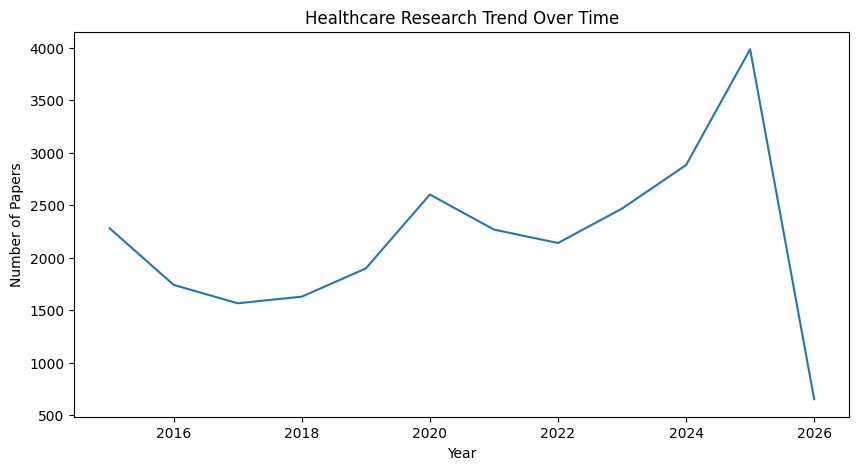

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
healthcare_df["year"] = pd.to_datetime(
    healthcare_df["update_date"]
).dt.year

trend = healthcare_df.groupby("year").size()

plt.figure(figsize=(10,5))
trend.plot()
plt.title("Healthcare Research Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.show()

In [38]:
doi_papers = healthcare_df[
    healthcare_df["doi"].notna()
]

print("Papers with DOI:", len(doi_papers))

Papers with DOI: 8672


In [ ]:
# dashboard